# Sprint 3 — Coding Attention Mechanisms
## Projeto LLM — Experimentos dos mecanismos de atenção

Este notebook reproduz, em um ambiente Google Colab autocontido, os componentes e experimentos da **Sprint 3 do Projeto LLM**, baseados no **Capítulo 3 (*Coding Attention Mechanisms*)** do livro *Build a Large Language Model (From Scratch)* (Sebastian Raschka, Manning, 2025).

**Autores:** Matheus Dapper, Vitória Aparecida Vendausen  
**Continuidade:** Conecta os embeddings gerados na Sprint 2 aos blocos de atenção que formarão o modelo Transformer completo na Sprint 4.

In [1]:
# ==============================================================================
# 0. CONFIGURAÇÃO DO AMBIENTE E IMPORTS
# ==============================================================================
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Semente fixa para reprodutibilidade estrita
torch.manual_seed(123)

print("PyTorch versão:", torch.__version__)
print("Dispositivo em uso:", "CUDA (GPU)" if torch.cuda.is_available() else "CPU")

PyTorch versão: 2.11.0+cpu
Dispositivo em uso: CPU


## 1. Scaled Dot-Product Attention
Operação matemática central da atenção:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}} + M\right) V$$
A divisão por $\sqrt{d_k}$ evita que o produto escalar atinja valores muito altos em dimensões elevadas, impedindo a saturação do Softmax e o desaparecimento dos gradientes.

In [2]:
# ==============================================================================
# 1. FUNÇÃO BASE: SCALED DOT-PRODUCT ATTENTION
# ==============================================================================
def scaled_dot_product_attention(Q, K, V, mask=None, scale=True, dropout_layer=None):
    """
    Calcula a atenção produto-escalar:
    Scores = (Q @ K^T) / sqrt(d_k) -> Mascara -> Softmax -> Dropout -> @ V
    """
    d_k = Q.size(-1)

    # 1. Similaridade entre tokens: (..., seq_q, seq_k)
    scores = torch.matmul(Q, K.transpose(-2, -1))

    # 2. Escala por sqrt(d_k)
    if scale:
        scores = scores / math.sqrt(d_k)

    # 3. Aplicação da máscara (substitui zeros por -infinito)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    # 4. Softmax na última dimensão (probabilidades somam 1.0 por linha)
    attention_weights = F.softmax(scores, dim=-1)

    # 5. Dropout aplicado aos pesos antes da ponderação dos valores
    if dropout_layer is not None:
        attention_weights = dropout_layer(attention_weights)

    # 6. Multiplicação pelos valores V
    output = torch.matmul(attention_weights, V)
    return output, attention_weights

# Validação com tensores sintéticos
q_val = torch.randn(1, 4, 32)
k_val = torch.randn(1, 4, 32)
v_val = torch.randn(1, 4, 32)

saida_val, pesos_val = scaled_dot_product_attention(q_val, k_val, v_val)
print("Validação do Scaled Dot-Product:")
print(f"  Shape Saída: {tuple(saida_val.shape)}")
print(f"  Shape Pesos: {tuple(pesos_val.shape)}")
print(f"  Soma da linha 0 dos pesos: {pesos_val[0, 0].sum().item():.4f}")

Validação do Scaled Dot-Product:
  Shape Saída: (1, 4, 32)
  Shape Pesos: (1, 4, 4)
  Soma da linha 0 dos pesos: 1.0000


## 2. Self-Attention (Auto-Atenção Simples)
Projeta a entrada $X$ em três representações usando camadas lineares com matrizes de pesos treináveis:
- **Query ($Q$):** Vetor que busca informações relevantes.
- **Key ($K$):** Vetor que serve como índice para ser consultado.
- **Value ($V$):** Conteúdo informativo que será retornado na média ponderada.

In [3]:
# ==============================================================================
# 2. CLASSE SELF-ATTENTION (SINGLE HEAD)
# ==============================================================================
class SelfAttention(nn.Module):
    def __init__(self, d_in, d_out, bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=bias)
        self.W_value = nn.Linear(d_in, d_out, bias=bias)
        self.out_proj = nn.Linear(d_out, d_out)

    def forward(self, x, mask=None, scale=True):
        Q = self.W_query(x)
        K = self.W_key(x)
        V = self.W_value(x)
        context_vecs, weights = scaled_dot_product_attention(Q, K, V, mask=mask, scale=scale)
        return self.out_proj(context_vecs), weights

# Teste com batch_size=2, seq_len=4, d_in=16
x_exemplo = torch.randn(2, 4, 16)
modelo_sa = SelfAttention(d_in=16, d_out=32)
saida_sa, pesos_sa = modelo_sa(x_exemplo)

print("Self-Attention:")
print(f"  Entrada: {tuple(x_exemplo.shape)}")
print(f"  Saída:   {tuple(saida_sa.shape)}")
print(f"  Pesos:   {tuple(pesos_sa.shape)}")

Self-Attention:
  Entrada: (2, 4, 16)
  Saída:   (2, 4, 32)
  Pesos:   (2, 4, 4)


## 3. Causal Attention (Atenção Autoregressiva)
Garante que a previsão do próximo token não tenha acesso a posições futuras na sequência. Uma máscara triangular inferior anula os pesos de posições $j > i$.

In [4]:
# ==============================================================================
# 3. CLASSE CAUSAL ATTENTION
# ==============================================================================
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout=0.0, bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=bias)
        self.W_value = nn.Linear(d_in, d_out, bias=bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        # Buffer de máscara não treinável
        self.register_buffer(
            "mask",
            torch.tril(torch.ones(context_length, context_length))
        )

    def forward(self, x):
        b, num_tokens, _ = x.shape
        Q = self.W_query(x)
        K = self.W_key(x)
        V = self.W_value(x)

        mask = self.mask[:num_tokens, :num_tokens].unsqueeze(0)
        context_vecs, weights = scaled_dot_product_attention(
            Q, K, V, mask=mask, dropout_layer=self.dropout
        )
        return self.out_proj(context_vecs), weights

modelo_causal = CausalAttention(d_in=16, d_out=16, context_length=4)
_, pesos_c = modelo_causal(x_exemplo)
print("Pesos da Atenção Causal (Lote 0):")
print(pesos_c[0].detach().cpu().numpy().round(3))

Pesos da Atenção Causal (Lote 0):
[[1.    0.    0.    0.   ]
 [0.472 0.528 0.    0.   ]
 [0.421 0.237 0.342 0.   ]
 [0.225 0.192 0.221 0.362]]


## 4. Multi-Head Attention (MHA)
Divide as representações em $h$ cabeças menores de dimensão $d_k = d_{\text{out}} / h$. O cálculo é vetorizado em paralelo para todas as cabeças e recombinado pela camada de projeção final.

In [5]:
# ==============================================================================
# 4. CLASSE MULTI-HEAD ATTENTION VETORIZADA
# ==============================================================================
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, num_heads, dropout=0.0, bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out precisa ser divisível por num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=bias)
        self.W_value = nn.Linear(d_in, d_out, bias=bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.tril(torch.ones(context_length, context_length))
        )

    def forward(self, x, is_causal=True):
        b, num_tokens, _ = x.shape

        # Projeção e separação em cabeças:
        # (b, tokens, d_out) -> (b, tokens, num_heads, head_dim) -> (b, num_heads, tokens, head_dim)
        Q = self.W_query(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.W_key(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.W_value(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        mask = self.mask[:num_tokens, :num_tokens].unsqueeze(0).unsqueeze(0) if is_causal else None

        context_vecs, weights = scaled_dot_product_attention(
            Q, K, V, mask=mask, dropout_layer=self.dropout
        )

        # Concatenação das cabeças: (b, num_heads, tokens, head_dim) -> (b, tokens, d_out)
        context_vecs = context_vecs.transpose(1, 2).contiguous().view(b, num_tokens, self.d_out)
        return self.out_proj(context_vecs), weights

modelo_mha = MultiHeadAttention(d_in=16, d_out=32, context_length=4, num_heads=4)
out_mha, w_mha = modelo_mha(x_exemplo)
print("Multi-Head Attention:")
print(f"  Shape Saída: {tuple(out_mha.shape)}")
print(f"  Shape Pesos (Batch, Heads, Tokens, Tokens): {tuple(w_mha.shape)}")

Multi-Head Attention:
  Shape Saída: (2, 4, 32)
  Shape Pesos (Batch, Heads, Tokens, Tokens): (2, 4, 4, 4)


## 5. Experimentação
Bateria sistemática de testes investigando:
1. **Com vs. Sem Escala:** Saturação do Softmax.
2. **Máscara Causal:** Verificação visual do triângulo inferior.
3. **Dimensões de Embedding:** Parâmetros e latência de processamento.
4. **Número de Heads e $d_k$:** Relação $d_k = d_{\text{out}} / h$.
5. **Multi-Head vs. Single-Head:** Visualização de mapas de calor por cabeça.
6. **Comprimento de Sequência ($T$):** Complexidade $O(T^2)$.

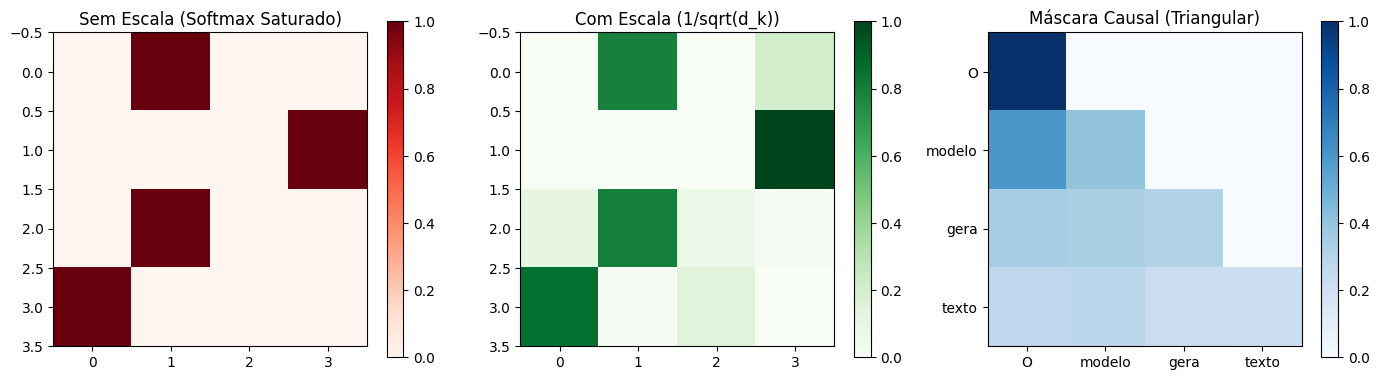

Maior probabilidade SEM escala: 1.0000
Maior probabilidade COM escala: 1.0000


In [6]:
# ==============================================================================
# EXPERIMENTO 5.1: COM VS SEM ESCALA & 5.2: MÁSCARA CAUSAL
# ==============================================================================
d_k_exp = 64
seq_exp = 4
Q_teste = torch.randn(1, seq_exp, d_k_exp) * 2.0
K_teste = torch.randn(1, seq_exp, d_k_exp) * 2.0
V_teste = torch.randn(1, seq_exp, d_k_exp)

_, w_sem = scaled_dot_product_attention(Q_teste, K_teste, V_teste, scale=False)
_, w_com = scaled_dot_product_attention(Q_teste, K_teste, V_teste, scale=True)

palavras = ["O", "modelo", "gera", "texto"]
x_causal_demo = torch.randn(1, len(palavras), 16)
m_causal_demo = CausalAttention(d_in=16, d_out=16, context_length=len(palavras))
_, w_causal_demo = m_causal_demo(x_causal_demo)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 3.8))

# 1. Sem Escala
im1 = ax1.imshow(w_sem[0].detach().cpu().numpy(), cmap="Reds", vmin=0, vmax=1)
ax1.set_title("Sem Escala (Softmax Saturado)")
fig.colorbar(im1, ax=ax1)

# 2. Com Escala
im2 = ax2.imshow(w_com[0].detach().cpu().numpy(), cmap="Greens", vmin=0, vmax=1)
ax2.set_title("Com Escala (1/sqrt(d_k))")
fig.colorbar(im2, ax=ax2)

# 3. Máscara Causal
im3 = ax3.imshow(w_causal_demo[0].detach().cpu().numpy(), cmap="Blues", vmin=0, vmax=1)
ax3.set_xticks(range(len(palavras)))
ax3.set_xticklabels(palavras)
ax3.set_yticks(range(len(palavras)))
ax3.set_yticklabels(palavras)
ax3.set_title("Máscara Causal (Triangular)")
fig.colorbar(im3, ax=ax3)

plt.tight_layout()
plt.show()

print(f"Maior probabilidade SEM escala: {w_sem.max().item():.4f}")
print(f"Maior probabilidade COM escala: {w_com.max().item():.4f}")

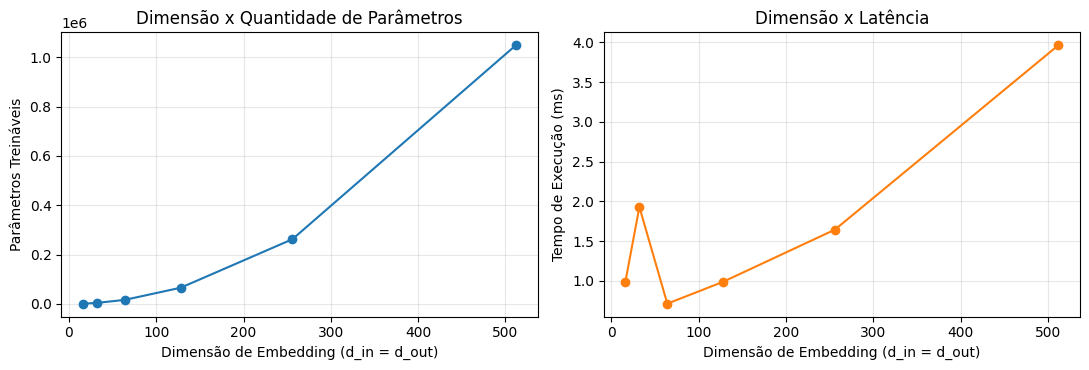


--- Relação Número de Heads x Dimensão d_k (com d_out = 64 fixo) ---
  Heads (h) = 1  | Head Dim (d_k) = 64 | Parâmetros = 16,448
  Heads (h) = 2  | Head Dim (d_k) = 32 | Parâmetros = 16,448
  Heads (h) = 4  | Head Dim (d_k) = 16 | Parâmetros = 16,448
  Heads (h) = 8  | Head Dim (d_k) = 8  | Parâmetros = 16,448


In [7]:
# ==============================================================================
# EXPERIMENTO 5.3: DIMENSÕES DE EMBEDDING & 5.4: NÚMERO DE HEADS E d_k
# ==============================================================================
dims = [16, 32, 64, 128, 256, 512]
seq_ctx = 8
params_list = []
tempos_list = []

for d in dims:
    m = MultiHeadAttention(d_in=d, d_out=d, context_length=seq_ctx, num_heads=4)
    x = torch.randn(4, seq_ctx, d)

    t0 = time.perf_counter()
    _ = m(x)
    dt = (time.perf_counter() - t0) * 1000

    total_p = sum(p.numel() for p in m.parameters())
    params_list.append(total_p)
    tempos_list.append(dt)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.plot(dims, params_list, marker='o', color='tab:blue')
ax1.set_xlabel("Dimensão de Embedding (d_in = d_out)")
ax1.set_ylabel("Parâmetros Treináveis")
ax1.set_title("Dimensão x Quantidade de Parâmetros")
ax1.grid(alpha=0.3)

ax2.plot(dims, tempos_list, marker='o', color='tab:orange')
ax2.set_xlabel("Dimensão de Embedding (d_in = d_out)")
ax2.set_ylabel("Tempo de Execução (ms)")
ax2.set_title("Dimensão x Latência")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- Relação Número de Heads x Dimensão d_k (com d_out = 64 fixo) ---")
for h in [1, 2, 4, 8]:
    modelo_h = MultiHeadAttention(d_in=64, d_out=64, context_length=4, num_heads=h)
    print(f"  Heads (h) = {h:<2} | Head Dim (d_k) = {modelo_h.head_dim:<2} | Parâmetros = {sum(p.numel() for p in modelo_h.parameters()):,}")

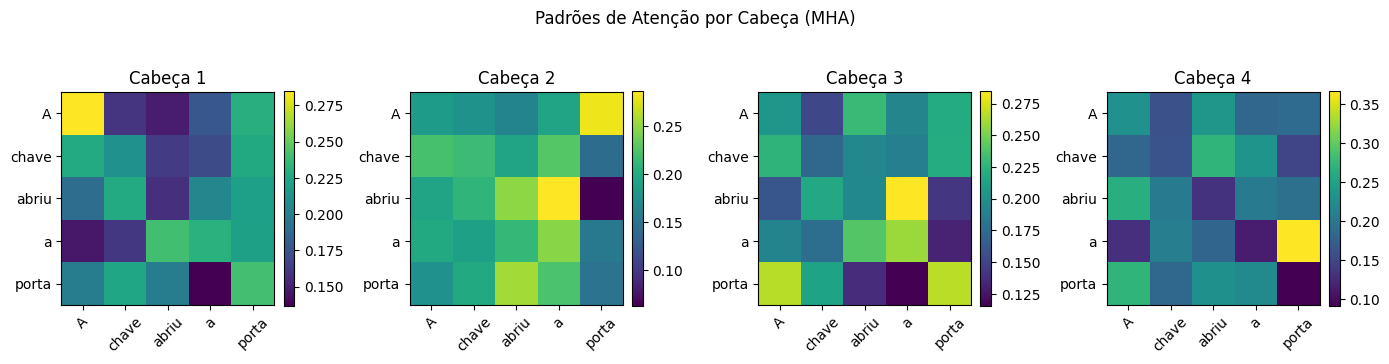

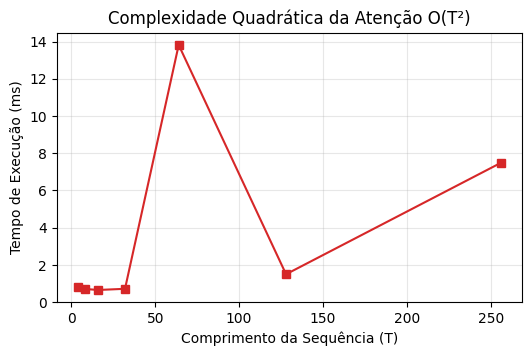

In [8]:
# ==============================================================================
# EXPERIMENTO 5.5: VISUALIZAÇÃO MULTI-HEAD & 5.6: COMPRIMENTO DE SEQUÊNCIA
# ==============================================================================
frase_demo = ["A", "chave", "abriu", "a", "porta"]
n_tokens = len(frase_demo)
x_frase = torch.randn(1, n_tokens, 32)

mha_vis = MultiHeadAttention(d_in=32, d_out=32, context_length=n_tokens, num_heads=4)
_, w_vis = mha_vis(x_frase, is_causal=False)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for i, ax in enumerate(axes):
    cax = ax.imshow(w_vis[0, i].detach().cpu().numpy(), cmap="viridis")
    ax.set_xticks(range(n_tokens))
    ax.set_xticklabels(frase_demo, rotation=45)
    ax.set_yticks(range(n_tokens))
    ax.set_yticklabels(frase_demo)
    ax.set_title(f"Cabeça {i+1}")
    fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Padrões de Atenção por Cabeça (MHA)", y=1.08)
plt.tight_layout()
plt.show()

# Complexidade O(T^2)
tamanhos_seq = [4, 8, 16, 32, 64, 128, 256]
tempos_seq = []

for T in tamanhos_seq:
    m_seq = MultiHeadAttention(d_in=32, d_out=32, context_length=T, num_heads=4)
    x_s = torch.randn(1, T, 32)
    t0 = time.perf_counter()
    _ = m_seq(x_s)
    tempos_seq.append((time.perf_counter() - t0) * 1000)

plt.figure(figsize=(6, 3.5))
plt.plot(tamanhos_seq, tempos_seq, marker='s', color='tab:red')
plt.xlabel("Comprimento da Sequência (T)")
plt.ylabel("Tempo de Execução (ms)")
plt.title("Complexidade Quadrática da Atenção O(T²)")
plt.grid(alpha=0.3)
plt.show()

## 6. Síntese dos Resultados

1. **Escala $\sqrt{d_k}$:** Impede que o produto escalar atinja magnitudes extremas, evitando a saturação do Softmax e garantindo gradientes estáveis durante o treinamento.
2. **Máscara Causal:** Zera rigorosamente as probabilidades de tokens futuros na matriz de atenção, preservando a dependência causal necessária no treinamento autoregressivo do GPT.
3. **Multi-Head Attention:** Permite que a rede atenda simultaneamente a informações em múltiplos subespaços de representação sem aumentar o número de parâmetros em relação a uma única cabeça equivalente.
4. **Custo Quadrático $O(T^2)$:** O tempo e o espaço de memória da atenção crescem com o quadrado do comprimento da sequência $T$, o que motiva técnicas de atenção eficiente para sequências muito longas.
5. **Conexão com a Sprint 4:** Os blocos de atenção aqui implementados serão combinados com conexões residuais (*residual connections*), normalização de camadas (*LayerNorm*) e redes neurais *feed-forward* (FFN) para a montagem dos blocos Transformer completos.